In [1]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

In [4]:
diabetes=load_diabetes()
df=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

#check the columns and description
print("Available Features:",df.columns.tolist())
print(diabetes.DESCR)


Available Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
   

In [6]:
#Set the target variable
df["disease_progression"]=diabetes.target

print(df.head())

        age       sex       bmi  ...        s5        s6  disease_progression
0  0.038076  0.050680  0.061696  ...  0.019907 -0.017646                151.0
1 -0.001882 -0.044642 -0.051474  ... -0.068332 -0.092204                 75.0
2  0.085299  0.050680  0.044451  ...  0.002861 -0.025930                141.0
3 -0.089063 -0.044642 -0.011595  ...  0.022688 -0.009362                206.0
4  0.005383 -0.044642 -0.036385  ... -0.031988 -0.046641                135.0

[5 rows x 11 columns]


In [7]:
#Check for missing values
print(df.isnull().sum())

age                    0
sex                    0
bmi                    0
bp                     0
s1                     0
s2                     0
s3                     0
s4                     0
s5                     0
s6                     0
disease_progression    0
dtype: int64


In [9]:
#Defining the feature (independent variable) and target (dependent variable)
X=df[["bmi"]] #BMI index
y=df["disease_progression"] #target

In [10]:
#split the data into traqining and testing sets (80% and 20% respectively)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 353
Testing set size: 89


In [11]:
#Cresting the Linear Regression Model
model=LinearRegression()

#Train the model on the training data
model.fit(X_train, y_train)

#Print the intercept and coefficient
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: 152.00335421448167
Coefficient: [998.57768914]


In [13]:
#Predict the results
y_pred=model.predict(X_test)

#Display the first few predictions alongside actual values
predictions=pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(predictions.head())

     Actual   Predicted
287   219.0  145.806227
211    70.0  188.857390
72    202.0  147.958785
321   230.0  203.925298
73    111.0  131.814599


### Model Performance Analysis & Observations

1. **Analysis of Predictions:**
   * The model successfully captures the general directional trend of the target variable.
   * However, using only `bmi` creates a rigid straight-line assumption. For example, in row **211**, the patient has a low actual progression (**70.0**) but a high BMI prediction (**188.86**).

2. **Why this happens:**
   * This is a **Simple Linear Regression** model. It lacks the context of other clinical indicators like blood pressure (`bp`) or insulin response markers (`s5`).

3. **Next Learning Steps:**
   * I will keep this single-variable baseline model as a point of comparison. 
   * In the next phase of learning, I will transition to **Multiple Linear Regression** to see how much adding the remaining 9 features reduces these individual prediction gaps.


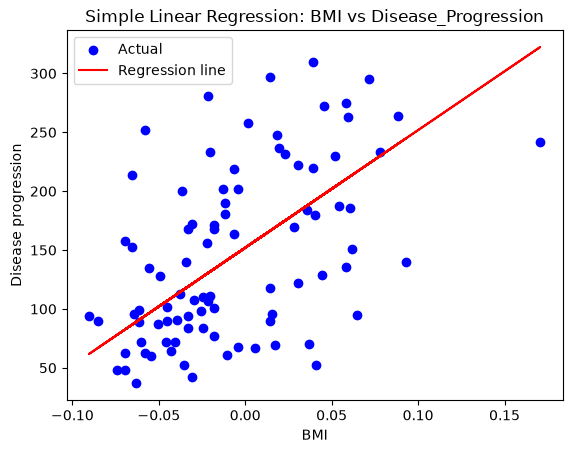

In [14]:
#Plot the actual data points
plt.scatter(X_test, y_test, color="blue", label="Actual")

#Plot the regression line
plt.plot(X_test, y_pred, color="red", label="Regression line")

#Add labels and title
plt.xlabel("BMI")
plt.ylabel("Disease progression")
plt.title("Simple Linear Regression: BMI vs Disease_Progression")
plt.legend()
plt.show()

In [15]:
#Evaluationg the model
mse=mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

r2=r2_score(y_test, y_pred)
print(f"R-Squared score: {r2}")

Mean Squared Error: 4061.8259284949268
R-Squared score: 0.23335039815872138


### Model Evaluation Metrics

* **Mean Squared Error (MSE):** `4061.83`
* **Root Mean Squared Error (RMSE):** `63.73` 
  * *Interpretation:* On average, our predictions deviate from the true disease progression score by approximately 63.7 units.
* **R-Squared ($R^2$) Score:** `0.2334`
  * *Interpretation:* Body Mass Index (BMI) alone explains roughly 23.3% of the variance in the target variable. This leaves 76.7% of the variance unexplained, confirming that a single-feature linear model underfits the complexity of the data.

This establishes a clear benchmark. The next phase will implement **Multiple Linear Regression** to minimize the RMSE and boost the $R^2$ score by introducing the remaining 9 features.
